In [ ]:
import torch
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from captum.attr import DeepLift
from src.model.data import DeepBurstDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from matplotlib import rcParams, rcParamsDefault

from src.model.constants import get_config
# from src.utils.visualization import plot_heatmap


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

#
# Training setup.
#
config_path = "configs/default.yaml"
config = get_config(config_path)


eid = 'E118'
remove_marks = None

if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []


seed = config["seed"]

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
npy_dir = "/Volumes/ExtremeSSD/BioStudy/CodeReview/burstformer/extra/datasets/processed/v1"

models = {}
datasets = {}
for fold in [0,1,2,3]:

    binsizes = [500]

    checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"


    meta_path = f"extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv"

    #
    # Setup end.
    #

    seed_everything(seed)
    meta = (
        pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
    )  # load and shuffle.

    # Split genes into two sets (train/val).
    genes = set(meta.gene_id.unique())
    n_genes = len(genes)
    print("Target genes:", len(genes))
    print(f"n_feats_p:{n_feats_p}")

    splits = {
        1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
        2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
        3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
        4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
    }

    chromosome_splits = {}
    for key, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = key

    qs = [
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
        meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
    ]

    train_genes = (
        qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
    )
    val_genes = qs[(fold + 3) % 4]

    print(len(train_genes), len(val_genes))

    val_dataset = DeepBurstDataset(
        meta_path,
        npy_dir,
        val_genes,
        i_max,
        binsizes,
        w_prom,
        w_max,
        config = config,
        with_gene_id=True
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz, num_workers=config['num_works'])

    model = DeepBurst(
        n_feats_p,
        
        d_emb,
        d_head,
        
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
        
    ).to(DEVICE)

    ckpt = torch.load(checkpoints,map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    models[fold] = DeepLift(model) 
    datasets[fold] = val_dataset


# 计算 DeepLIFT 归因（解释）值
LABEL_BIN_MAP = {
    "Low bs and low bf":"C1",
    "High bs and low bf":"C2",
    "Low bs and high bf":"C3",
    "High bs and high bf":"C4",
}
data = pd.read_csv(f'extra/results/{eid}_results.csv')
data = pd.merge(data,meta[['gene_id','chrom','start','strand']],how='inner',on='gene_id').sort_values(by='bf_label_score',ascending=False)
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]

Target genes: 14280
n_feats_p:7
10824 3456
Target genes: 14280
n_feats_p:7
10418 3862
Target genes: 14280
n_feats_p:7
10901 3379
Target genes: 14280
n_feats_p:7
10697 3583


FileNotFoundError: [Errno 2] No such file or directory: 'extra/results/E118_results.csv'

In [ ]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 8 ,
        'axes.titleweight' :'bold',
        'axes.titlesize': 10,  # Title font size
        
        'figure.titleweight' : 'bold' ,
        'figure.titlesize' : 8 ,
        
        'axes.labelsize' : 8 ,
        'axes.labelpad' : 2 ,
        # 'axes.labelweight' : 'bold' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'xtick.labelsize' : 7 ,
        'ytick.labelsize' : 7 ,
        
        'legend.fontsize' : 8 ,
        'figure.figsize' : (16/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")


## BF Feature Importance

In [6]:

label_bin = 'Low bs and low bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)



  0%|          | 0/1213 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 1039/1039 [00:28<00:00, 36.36it/s]


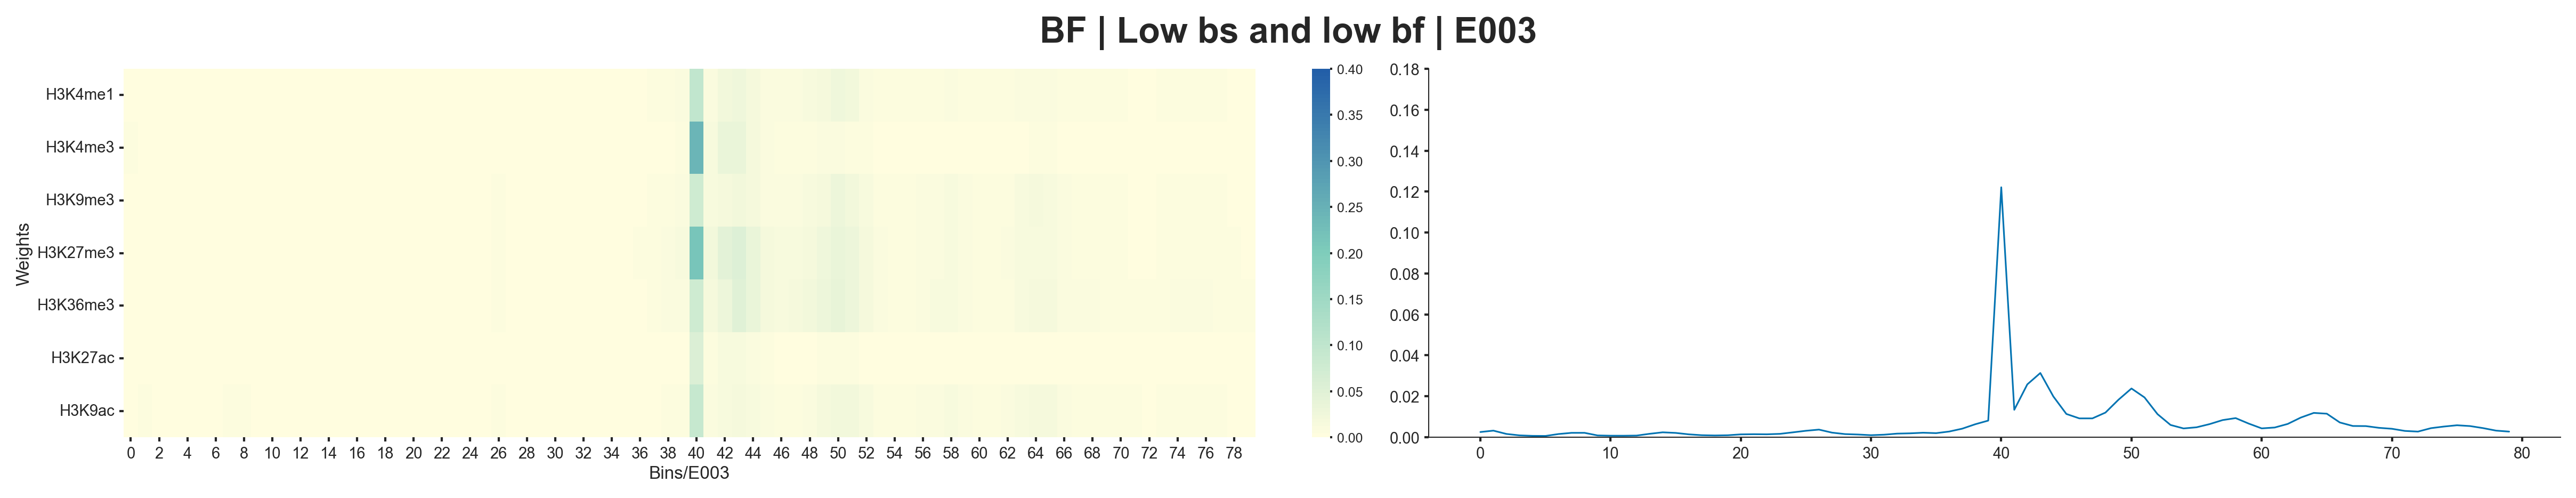

In [7]:

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))


plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1)) 

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {label_bin} | {eid}", fontsize=16)

plt.show()

In [8]:
label_bin = 'High bs and high bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


  0%|          | 0/1083 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 1232/1232 [00:34<00:00, 35.88it/s]


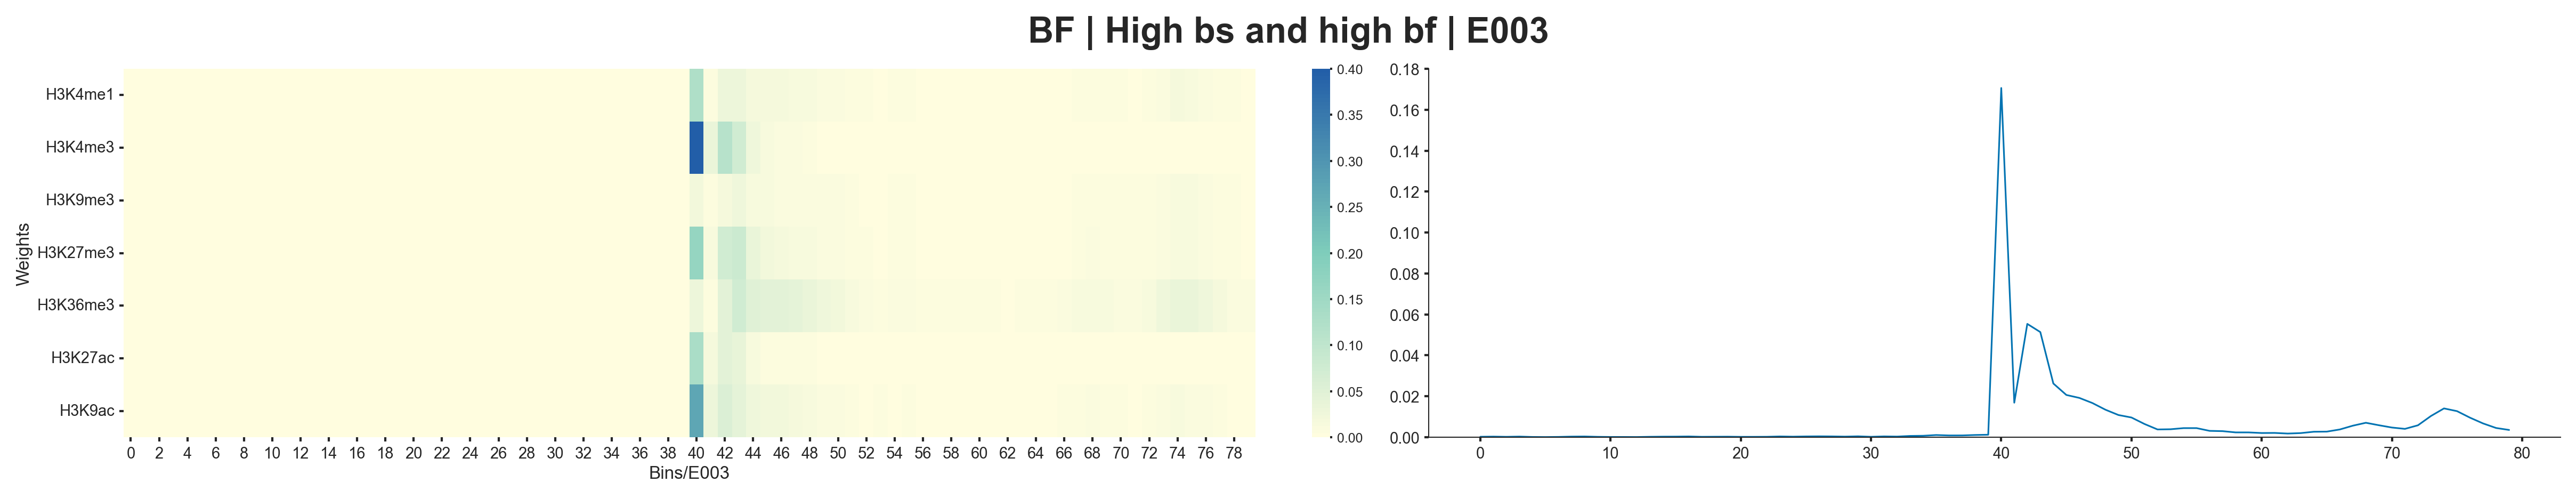

In [9]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {label_bin} | {eid}", fontsize=16)
plt.show()

In [10]:
label_bin = 'High bs and low bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


  0%|          | 0/601 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 587/587 [00:16<00:00, 36.35it/s]


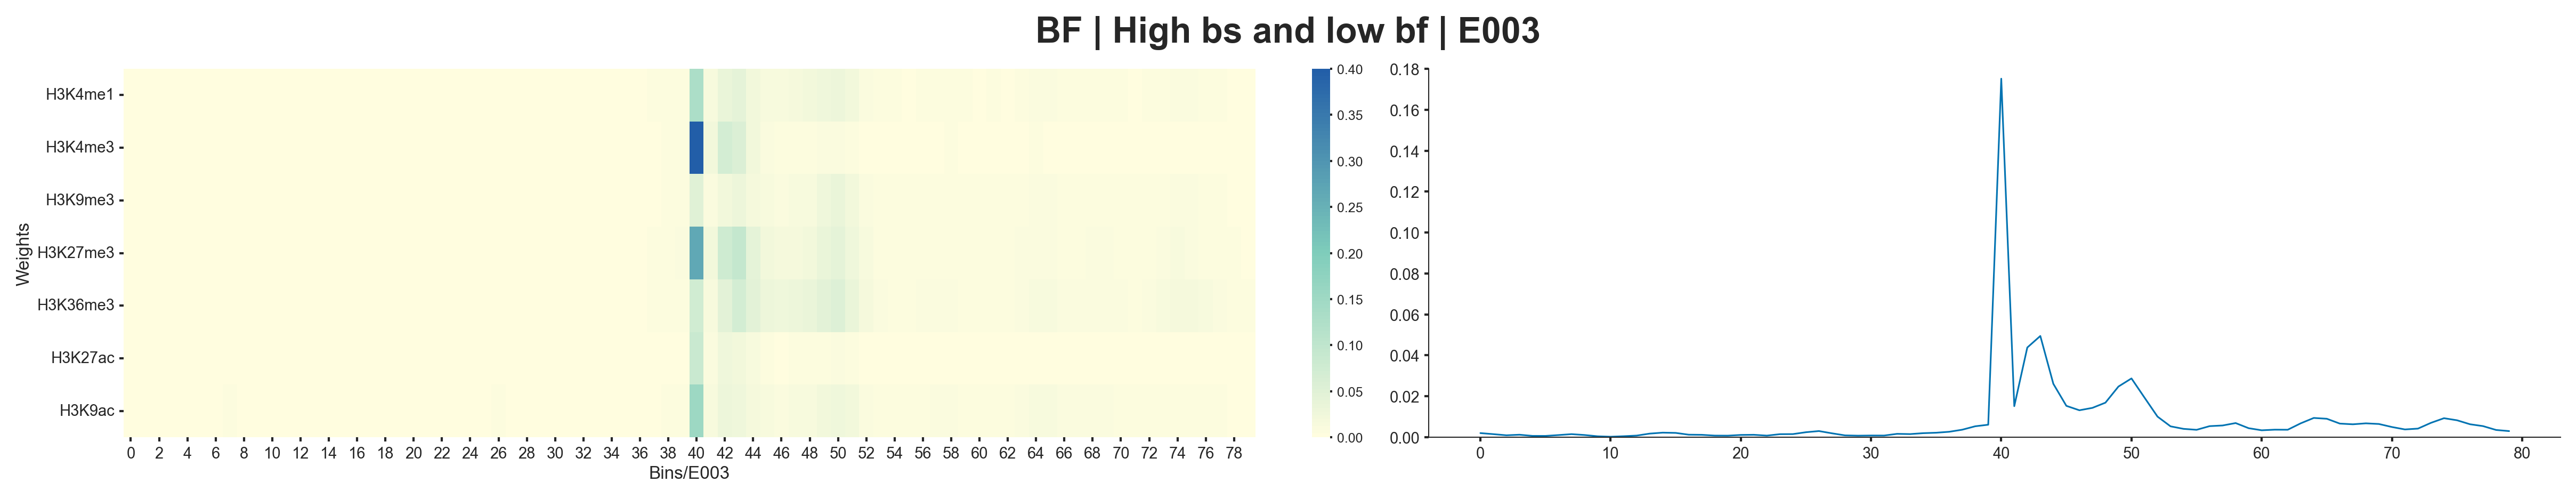

In [11]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {label_bin} | {eid}", fontsize=16)
plt.show()

In [12]:
label_bin = 'Low bs and high bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


  0%|          | 0/588 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 592/592 [00:17<00:00, 34.69it/s]


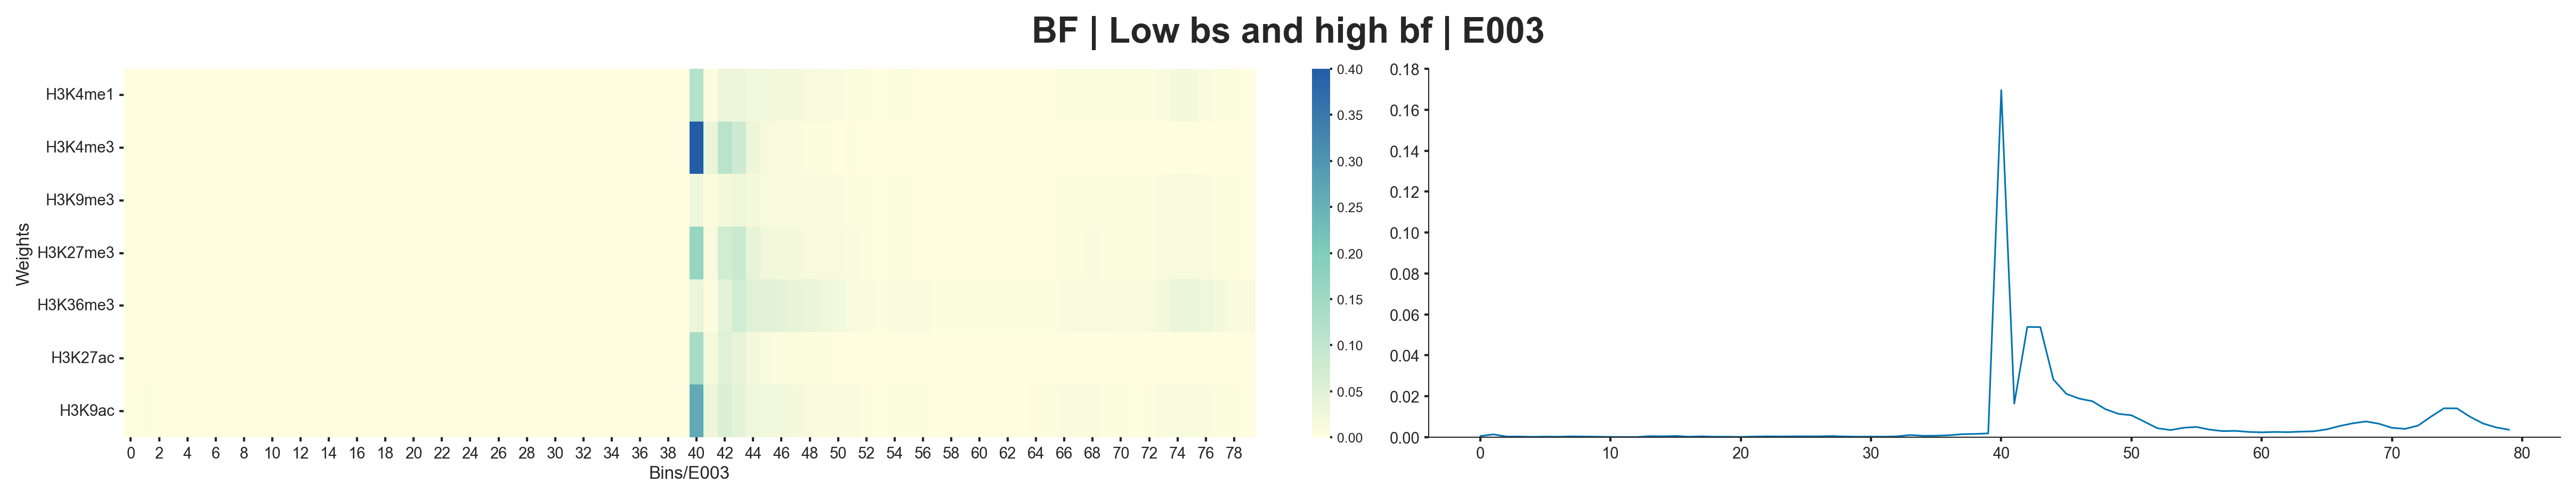

In [13]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {label_bin} | {eid}", fontsize=16)
plt.show()

In [26]:
import scipy
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rcParamsDefault
from typing import List, Union
import pandas as pd 
import numpy as np
from matplotlib.colors import Normalize, ListedColormap,LinearSegmentedColormap


def plot_heatmap(weight_matrix,axis=None,title=None, xlabel=None,ylabel="Locations",xticks = None,xticklabels=None,yticks=None,yticklabels=None,vmin=0,vmax=0.4):
    """
    Plots a clustered heatmap of the weights in a given subnetwork.

    Parameters:
    weight_matrix (DataFrame): A matrix containing the weights of edges in the subnetwork.
    output_path (str): The path where the output plot will be saved.

    Returns:
    None
    """
    
    # Define colors for the heatmap
    COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]


    g = sns.heatmap(weight_matrix, cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100),ax=axis,vmin=vmin, vmax=vmax)
    if xticks:
        g.set_xticks(xticks)

    if yticks:
        g.set_yticks(yticks)


    # Set the font size and name for x-axis tick labels, and rotate them for better visibility
    # g.set_xticklabels(axis.get_xticklabels(), fontsize=6, rotation=50)

    # Set the font size and name for y-axis tick labels
    # g.set_yticklabels(axis.get_yticklabels(), rotation=360)

    # Customize tick parameters for the heatmap axes
    # g.tick_params(axis='both', which='major', length=0)

    # Adjust the colorbar tick parameters if collections exist
    if g.collections:
        g.collections[0].colorbar.ax.tick_params(labelsize=6, length=1)

    # Set labels for the x-axis and y-axis
    if xlabel:
        g.set_xlabel(xlabel)
    
    if ylabel:
        g.set_ylabel(ylabel)

    if xticklabels:
        g.set_xticklabels(xticklabels)

    if yticklabels:
        axis.set_yticklabels(yticklabels,rotation=360)

    g.set_title(title)


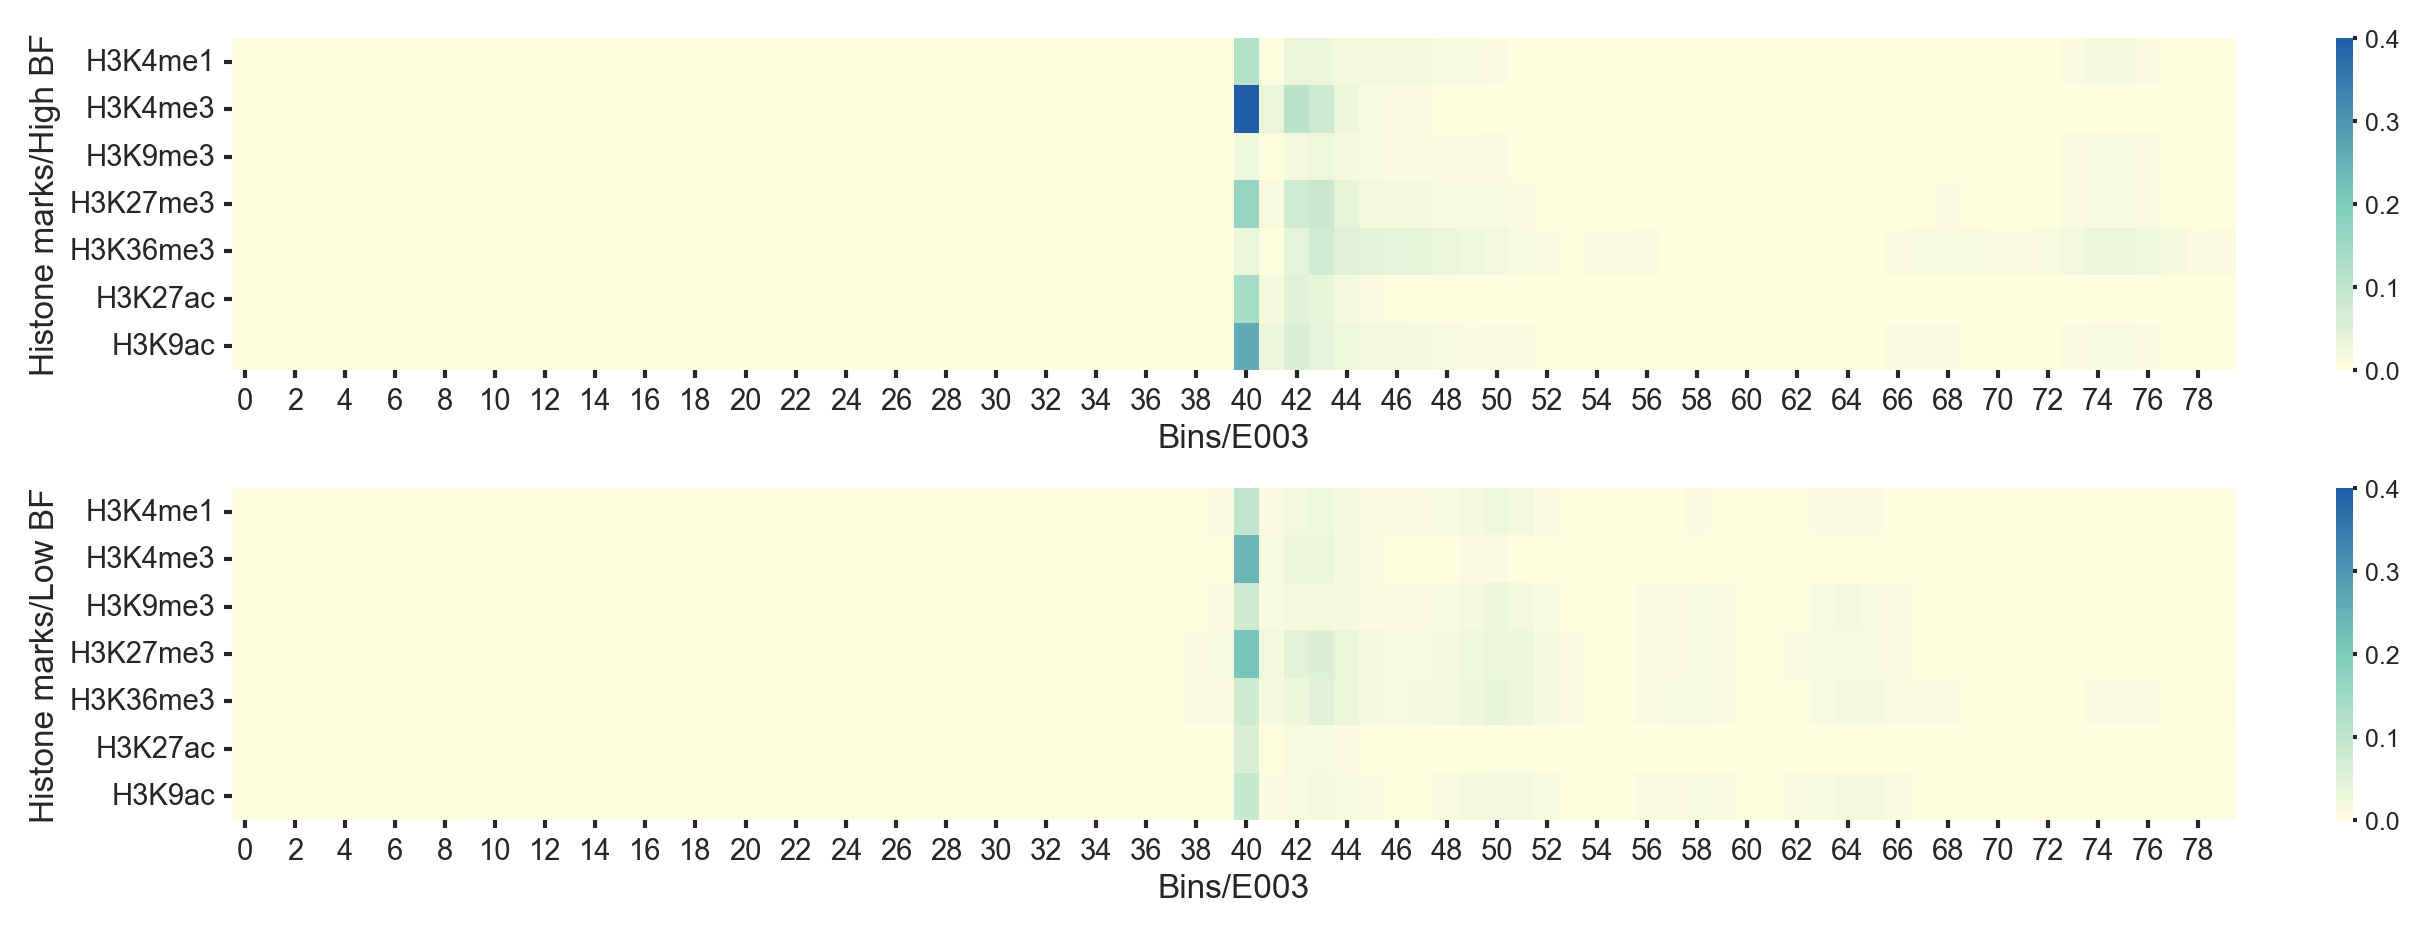

In [15]:
label_bin = 'Low bs and high bf'
with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)

label_bin = 'Low bs and low bf'
with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)

fig, ax =plt.subplots(2,1,constrained_layout=True, figsize=(8, 3))

plot_heatmap(attributions1,axis=ax[0],xlabel=f"Bins/{eid}",ylabel="Histone marks/High BF",yticks=MARKS)
plot_heatmap(attributions2,axis=ax[1],xlabel=f"Bins/{eid}",ylabel="Histone marks/Low BF",yticks=MARKS)

# fig.suptitle("Attribution heatmap")
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

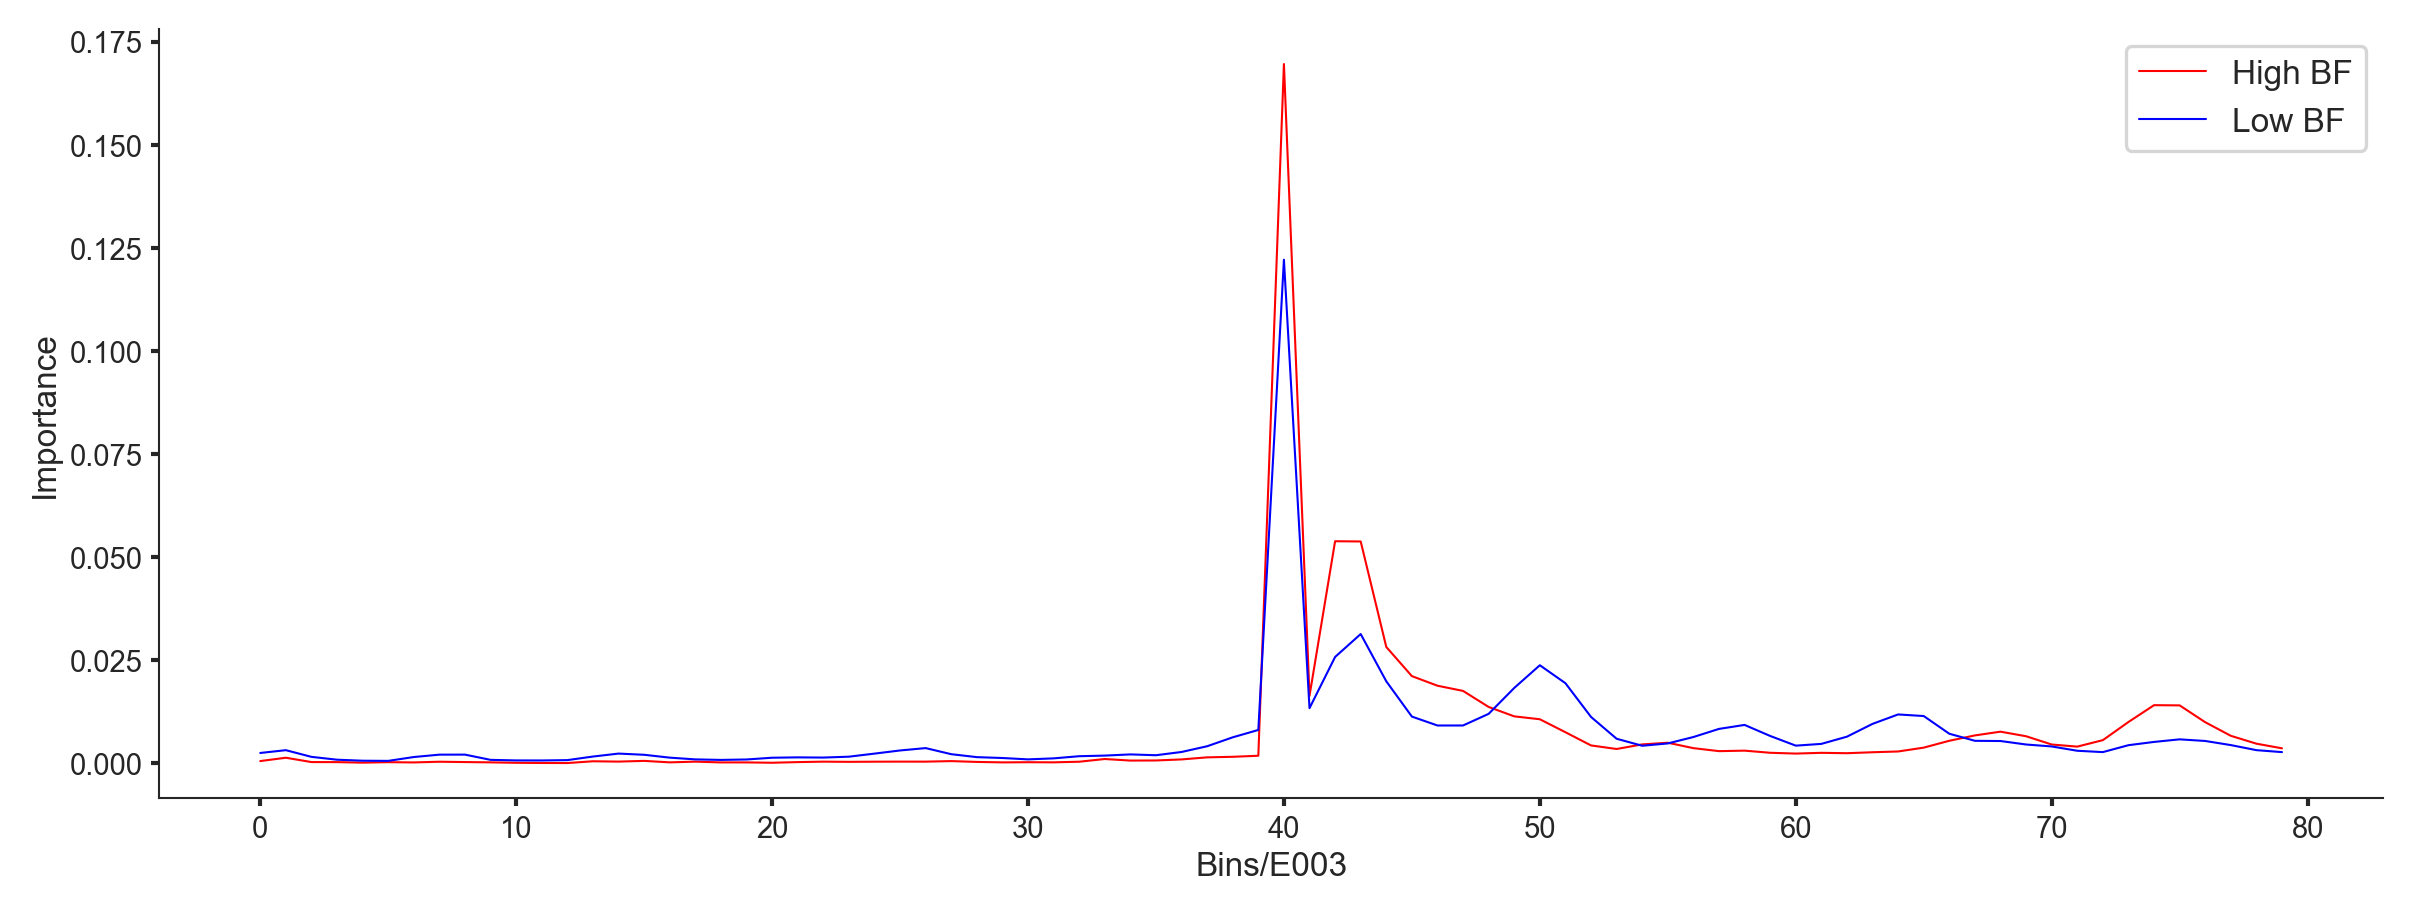

In [16]:

label_bin = 'Low bs and high bf'
with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

label_bin = 'Low bs and low bf'
with open(f'extra/results/{eid}_bf_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

fig = plt.figure(1,figsize=(8,3))

g1 = sns.lineplot(distribution1, color='red', linewidth=0.5,label = 'High BF')
g2 = sns.lineplot(distribution2, color='blue', linewidth=0.5,label = 'Low BF')
# Adjust layout to ensure everything fits
plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Importance")
plt.show()


## BS Feature Importance

In [17]:

label_bin = 'Low bs and low bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)



  0%|          | 0/1213 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 1039/1039 [00:30<00:00, 34.07it/s]


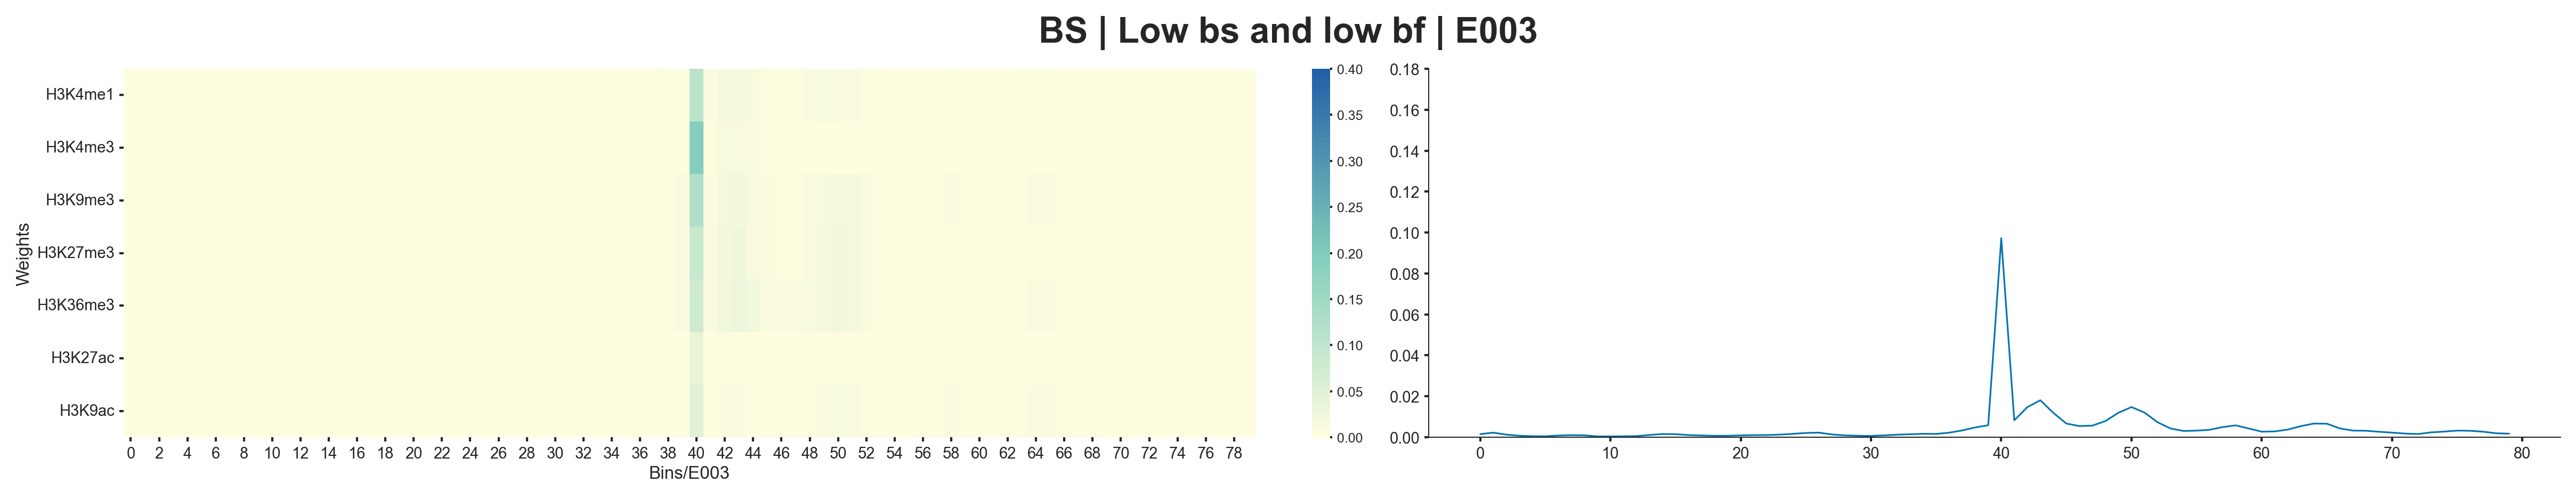

In [18]:

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))

plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {label_bin} | {eid}", fontsize=16)
plt.show()

In [19]:
label_bin = 'High bs and high bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


  0%|          | 0/1083 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
 12%|█▏        | 125/1083 [00:03<00:29, 32.07it/s]


KeyboardInterrupt: 

In [ ]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {label_bin} | {eid}", fontsize=16)
plt.show()

In [ ]:
label_bin = 'High bs and low bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


In [ ]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {label_bin} | {eid}", fontsize=16)
plt.show()

In [ ]:
label_bin = 'Low bs and high bf'
gene_ids = data[(data['labels_marks']==LABEL_BIN_MAP[label_bin])]


attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


In [ ]:
fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticks=MARKS)

distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {label_bin} | {eid}", fontsize=16)
plt.show()

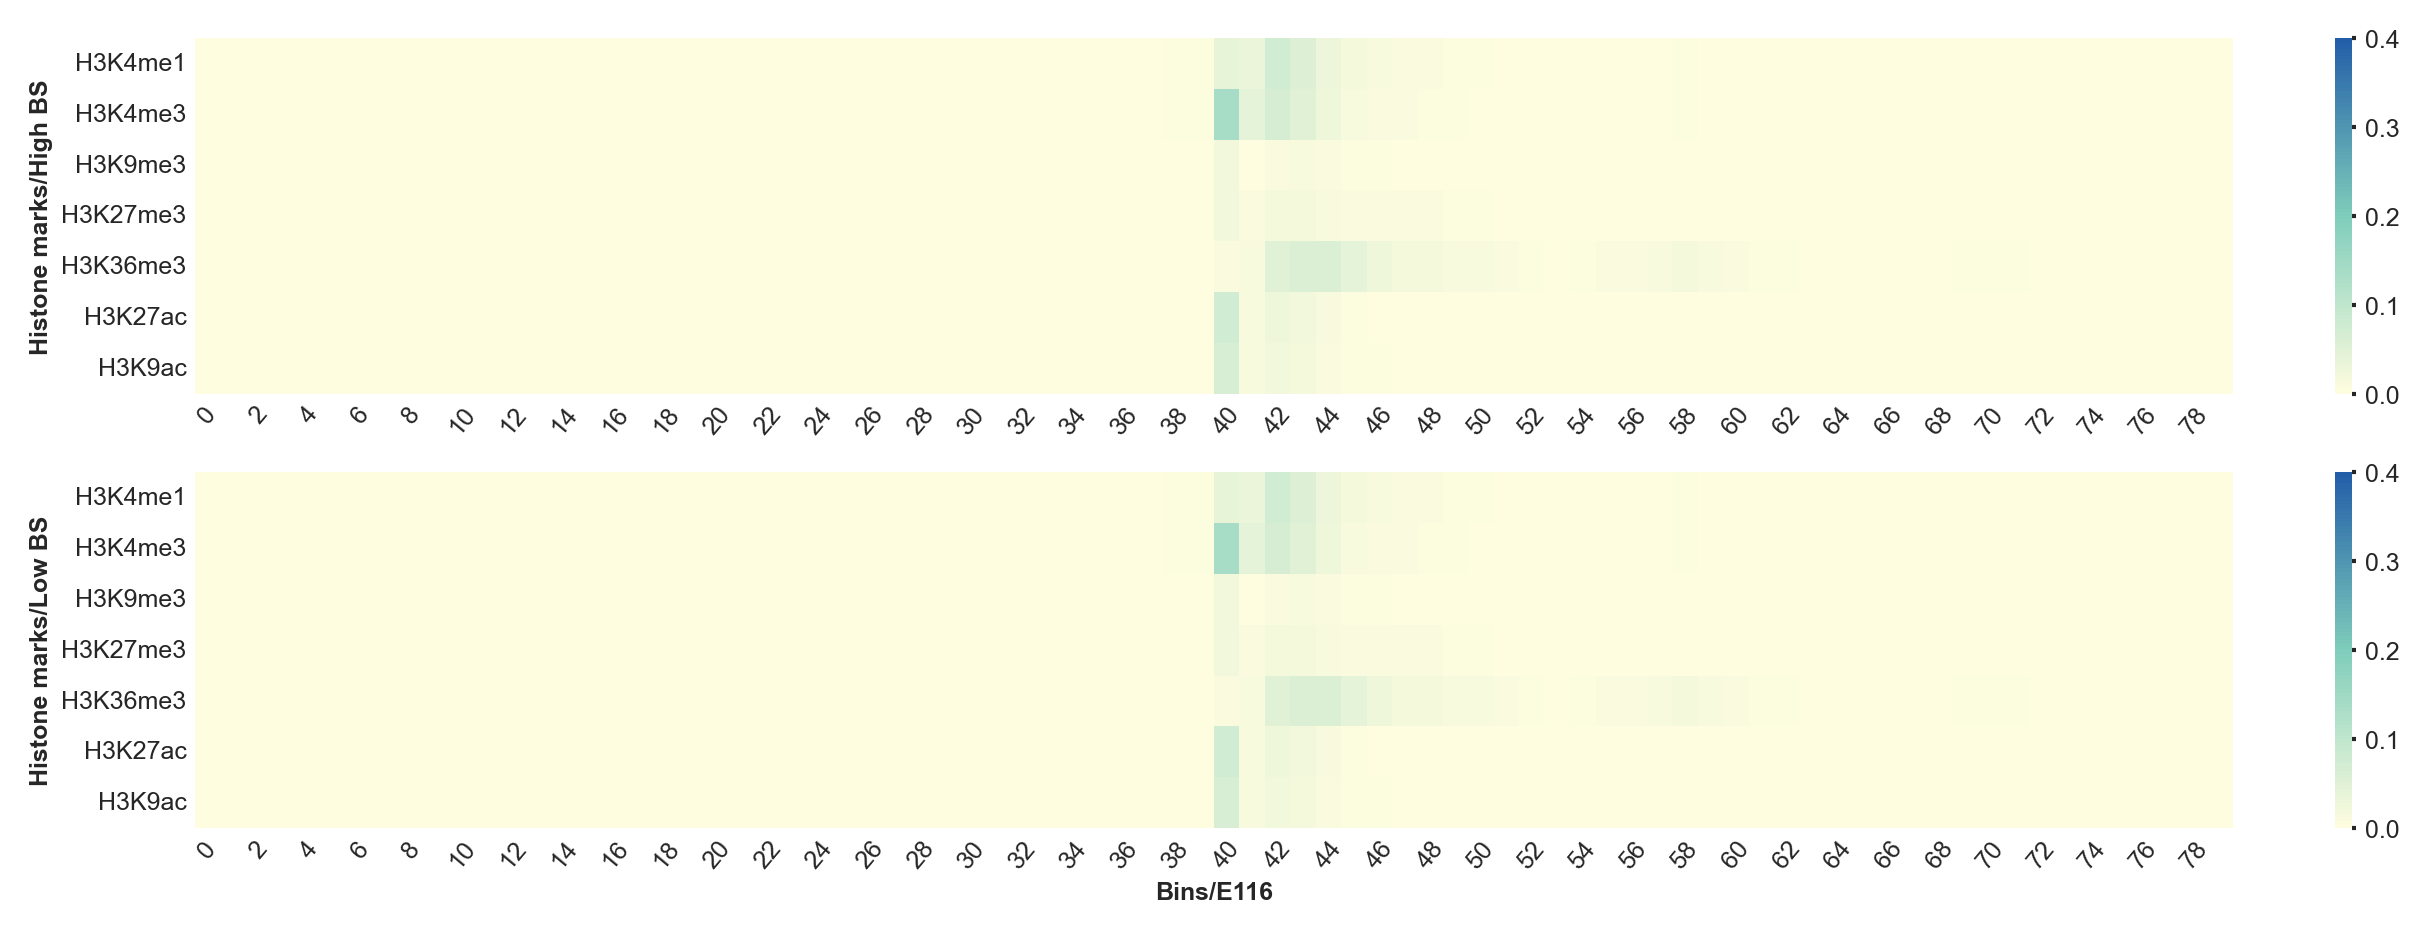

In [ ]:
label_bin = 'Low bs and high bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)

label_bin = 'Low bs and low bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)

fig, ax =plt.subplots(2,1,constrained_layout=True, figsize=(8, 3))

plot_heatmap(attributions1,axis=ax[0],xlabel=f"Bins/{eid}",ylabel="Histone marks/High BS",yticks=MARKS)
plot_heatmap(attributions2,axis=ax[1],xlabel=f"Bins/{eid}",ylabel="Histone marks/Low BS",yticks=MARKS)

# fig.suptitle("Attribution heatmap")
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

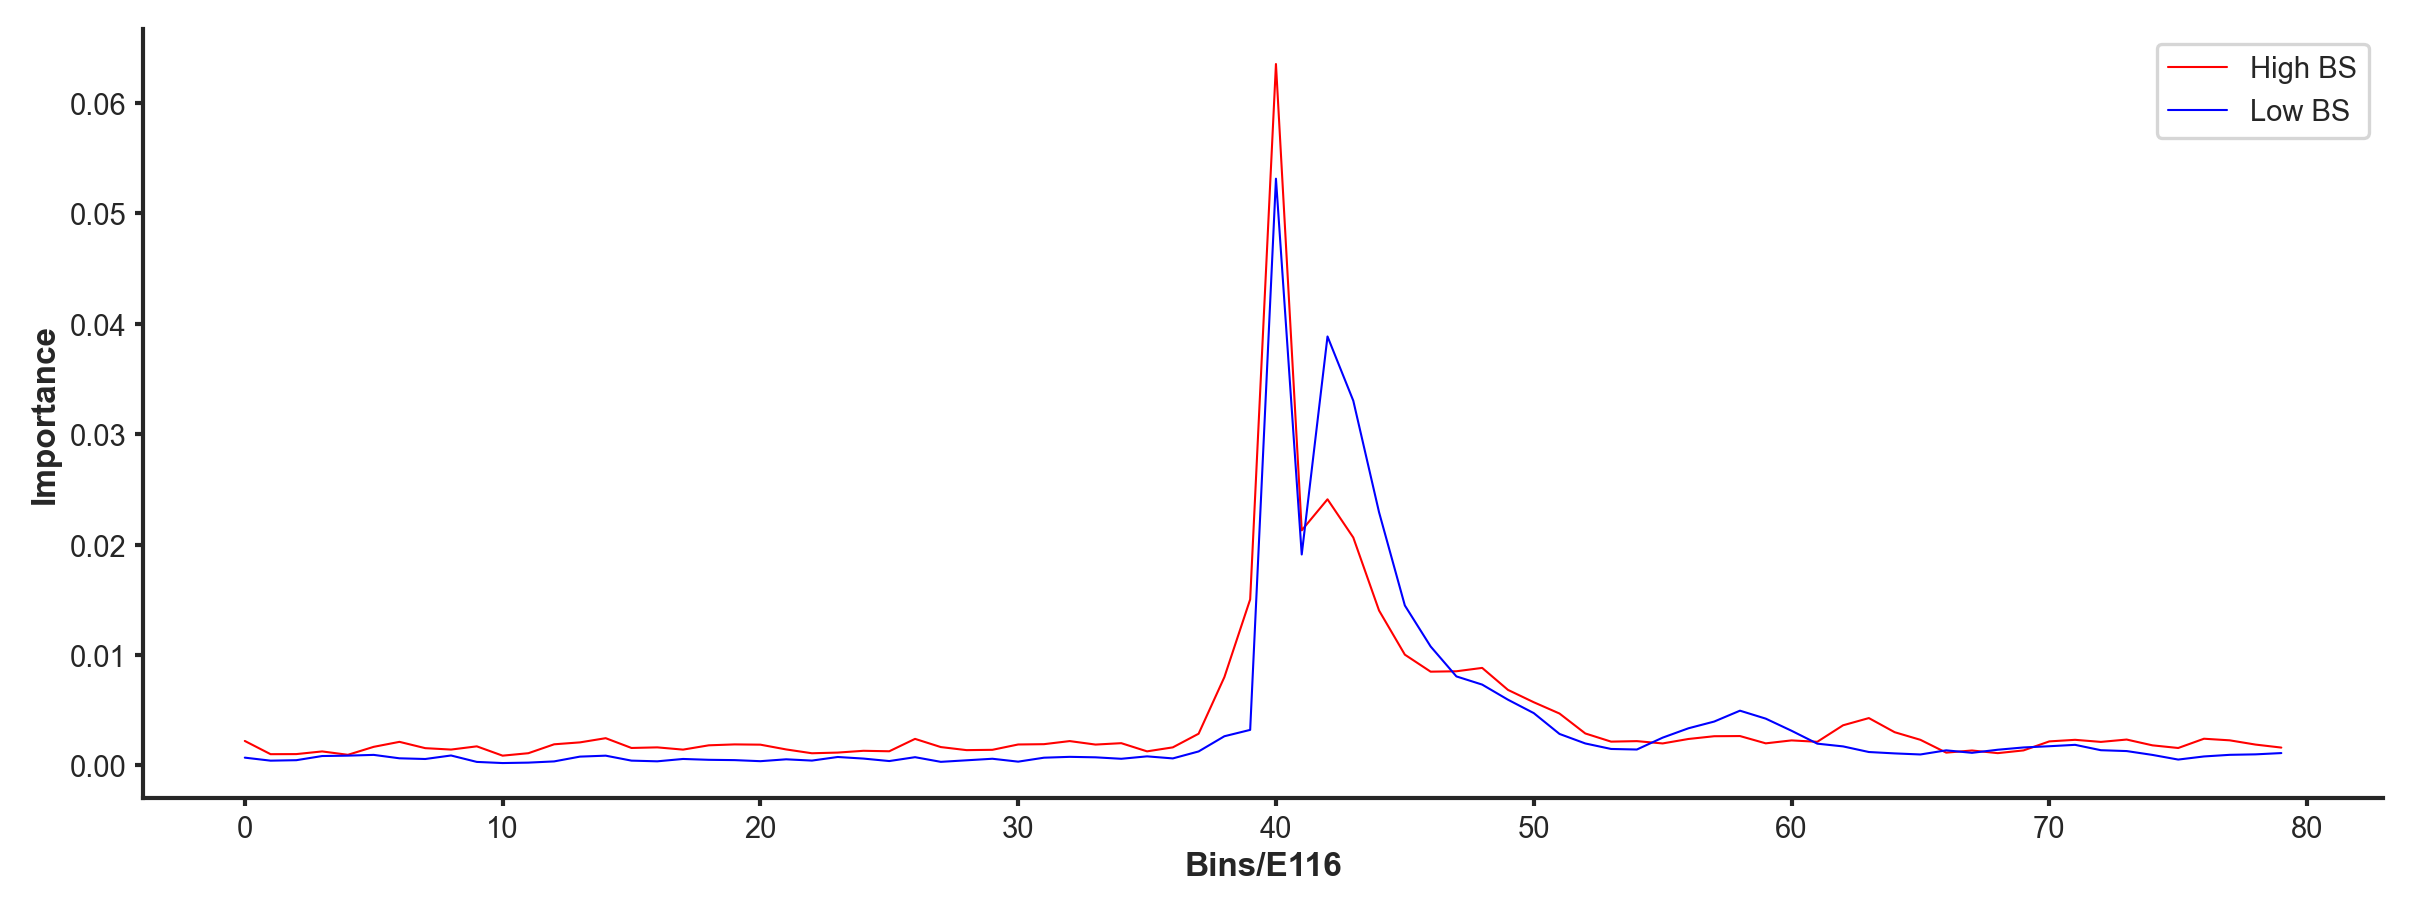

In [ ]:
label_bin = 'High bs and low bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

label_bin = 'Low bs and low bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

fig = plt.figure(1,figsize=(8,3))
g1 = sns.lineplot(distribution1, color='red', linewidth=0.5,label = 'High BS')
g2 = sns.lineplot(distribution2, color='blue', linewidth=0.5,label = 'Low BS')
# Adjust layout to ensure everything fits
plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Importance")
plt.show()

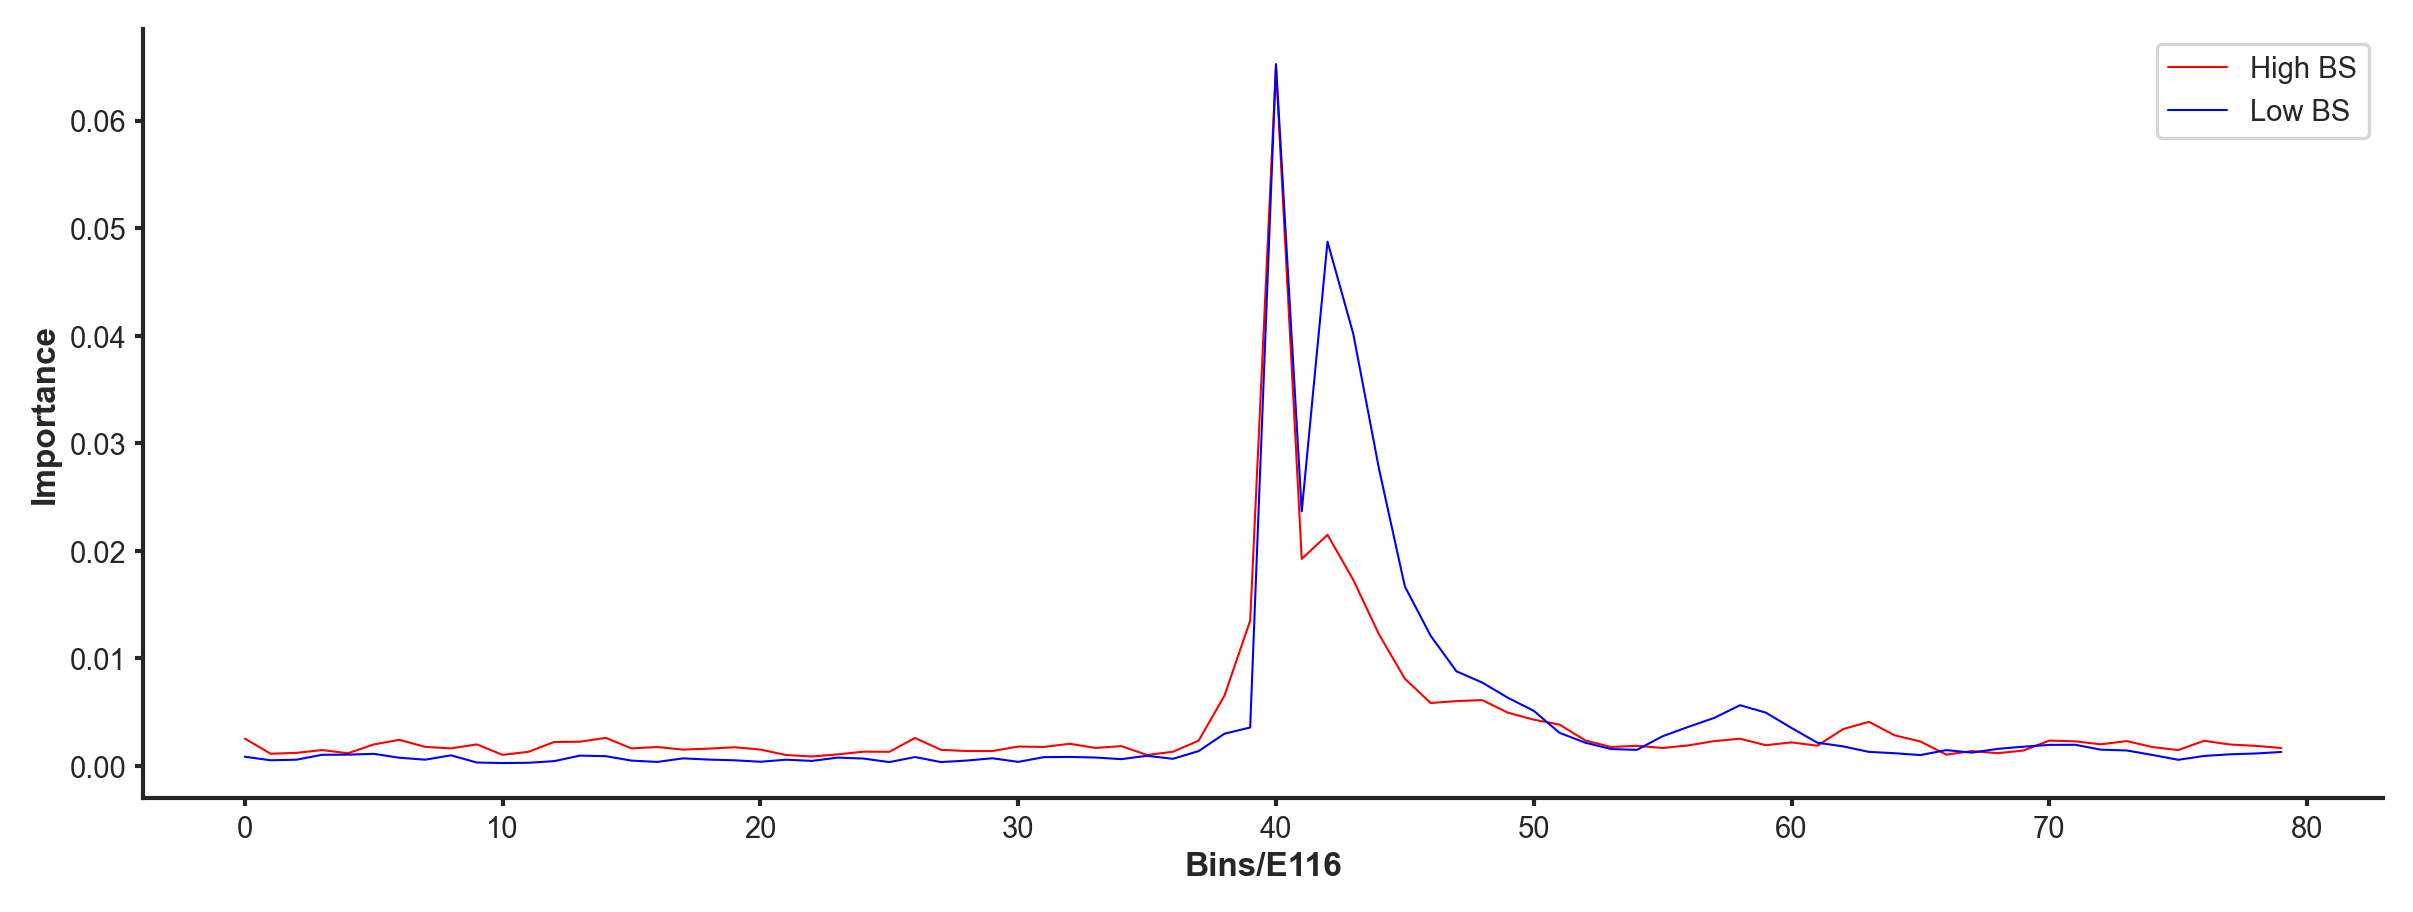

In [ ]:
label_bin = 'High bs and low bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)

label_bin = 'Low bs and low bf'
with open(f'extra/results/{eid}_bs_{LABEL_BIN_MAP[label_bin]}_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)

fig = plt.figure(1,figsize=(8,3))

distribution1_active = attributions1[[0,1,4,5,6]]
distribution1_repressive = attributions1[[2,3]]


distribution2_active = attributions2[[0,1,4,5,6]]
distribution2_repressive = attributions2[[2,3]]

g1 = sns.lineplot(np.mean(distribution1_active,axis=0), color='red', linewidth=0.5,label = 'High BS')
g2 = sns.lineplot(np.mean(distribution2_active,axis=0), color='blue', linewidth=0.5,label = 'Low BS')
# Adjust layout to ensure everything fits
plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
plt.ylabel(f"Importance")
plt.show()

# All BS BF

  0%|          | 0/3355 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3492/3492 [01:38<00:00, 35.47it/s]


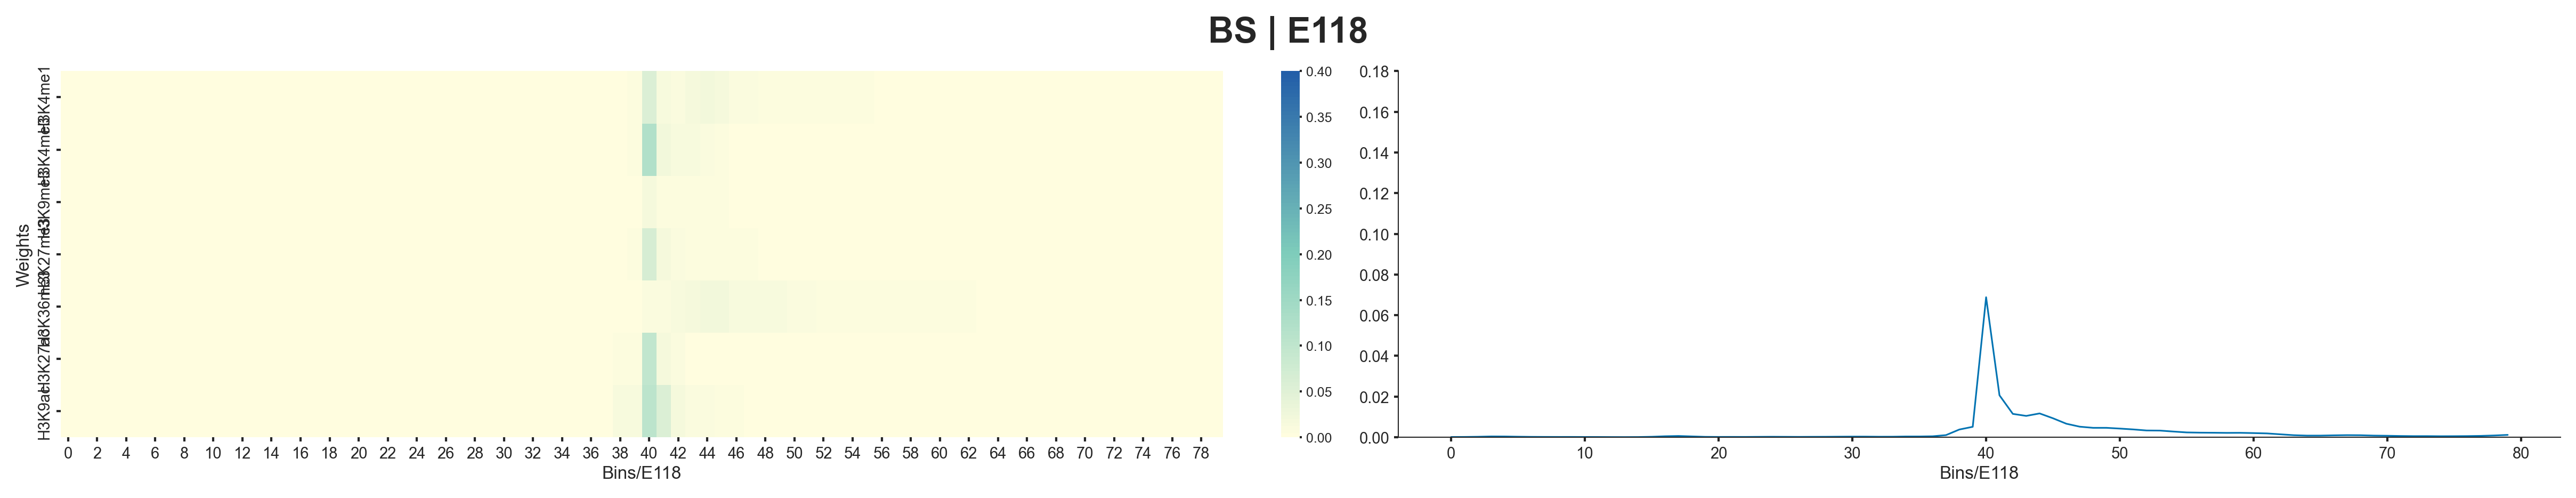

In [30]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=1)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)

g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BS | {eid}", fontsize=16)
# fig.suptitle("Attribution heatmap")
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()


  0%|          | 0/3355 [00:00<?, ?it/s]/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/_utils/gradient.py:57: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  warnings.warn(
/Users/wanghan/miniforge3/envs/DeepBurst/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(
100%|██████████| 3492/3492 [01:43<00:00, 33.68it/s]


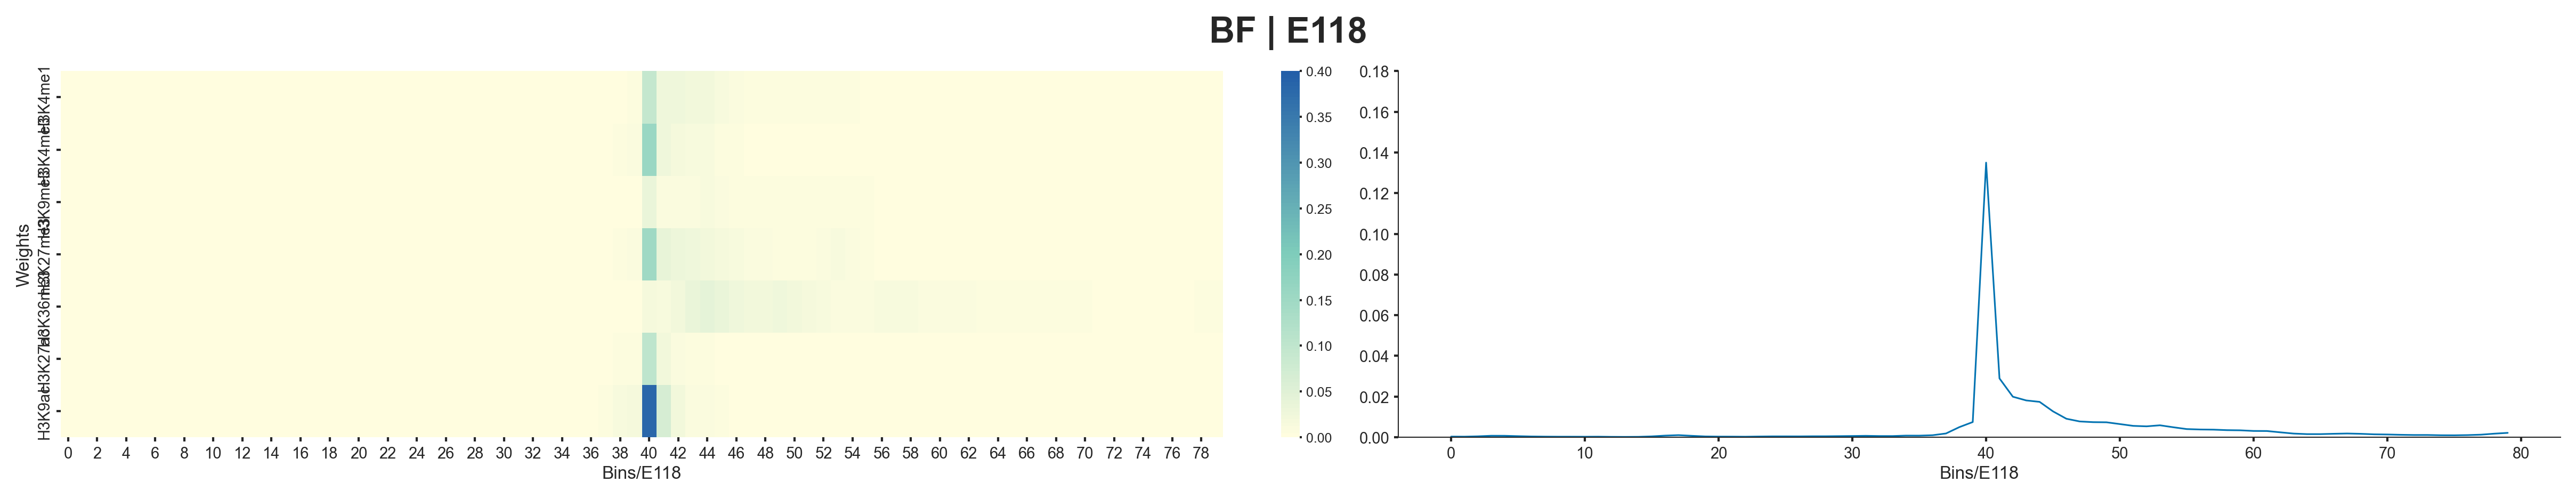

In [31]:
gene_ids = data

attributions = []
for fold in [0,1,2,3]:
    for row in tqdm(gene_ids[gene_ids['fold']==fold].to_records()):

        gene_id = row['gene_id']
        sample = val_dataset.get_sample(gene_id=gene_id,add_bsz_dim=True)

        w = models[fold].attribute(inputs=(sample['promoter_feats'][500]), target=3)
        w = abs(np.transpose(w.detach().numpy()[0][0]))
        attributions.append(w)


distribution = np.mean(attributions,axis=(0,1))

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','wb') as w:
    np.save(w,np.mean(attributions,axis=0))

with open(f'extra/results/{eid}_bf_deeplift_distribution.npy','wb') as w:
    np.save(w,distribution)

fig, ax =plt.subplots(1,2,constrained_layout=True, figsize=(16, 3))
plot_heatmap(np.mean(attributions,axis=0),axis=ax[0],xlabel=f"Bins/{eid}", ylabel="Weights",yticklabels=MARKS)


g = sns.lineplot(distribution,ax=ax[1])
g.set_ylim(0,0.18)
fig.suptitle(f"BF | {eid}", fontsize=16)
# Adjust layout to ensure everything fits
# plt.tight_layout()
plt.xlabel(f"Bins/{eid}")
# plt.ylabel(f"Importance")
plt.show()

### BS BF Attributions HeatMap

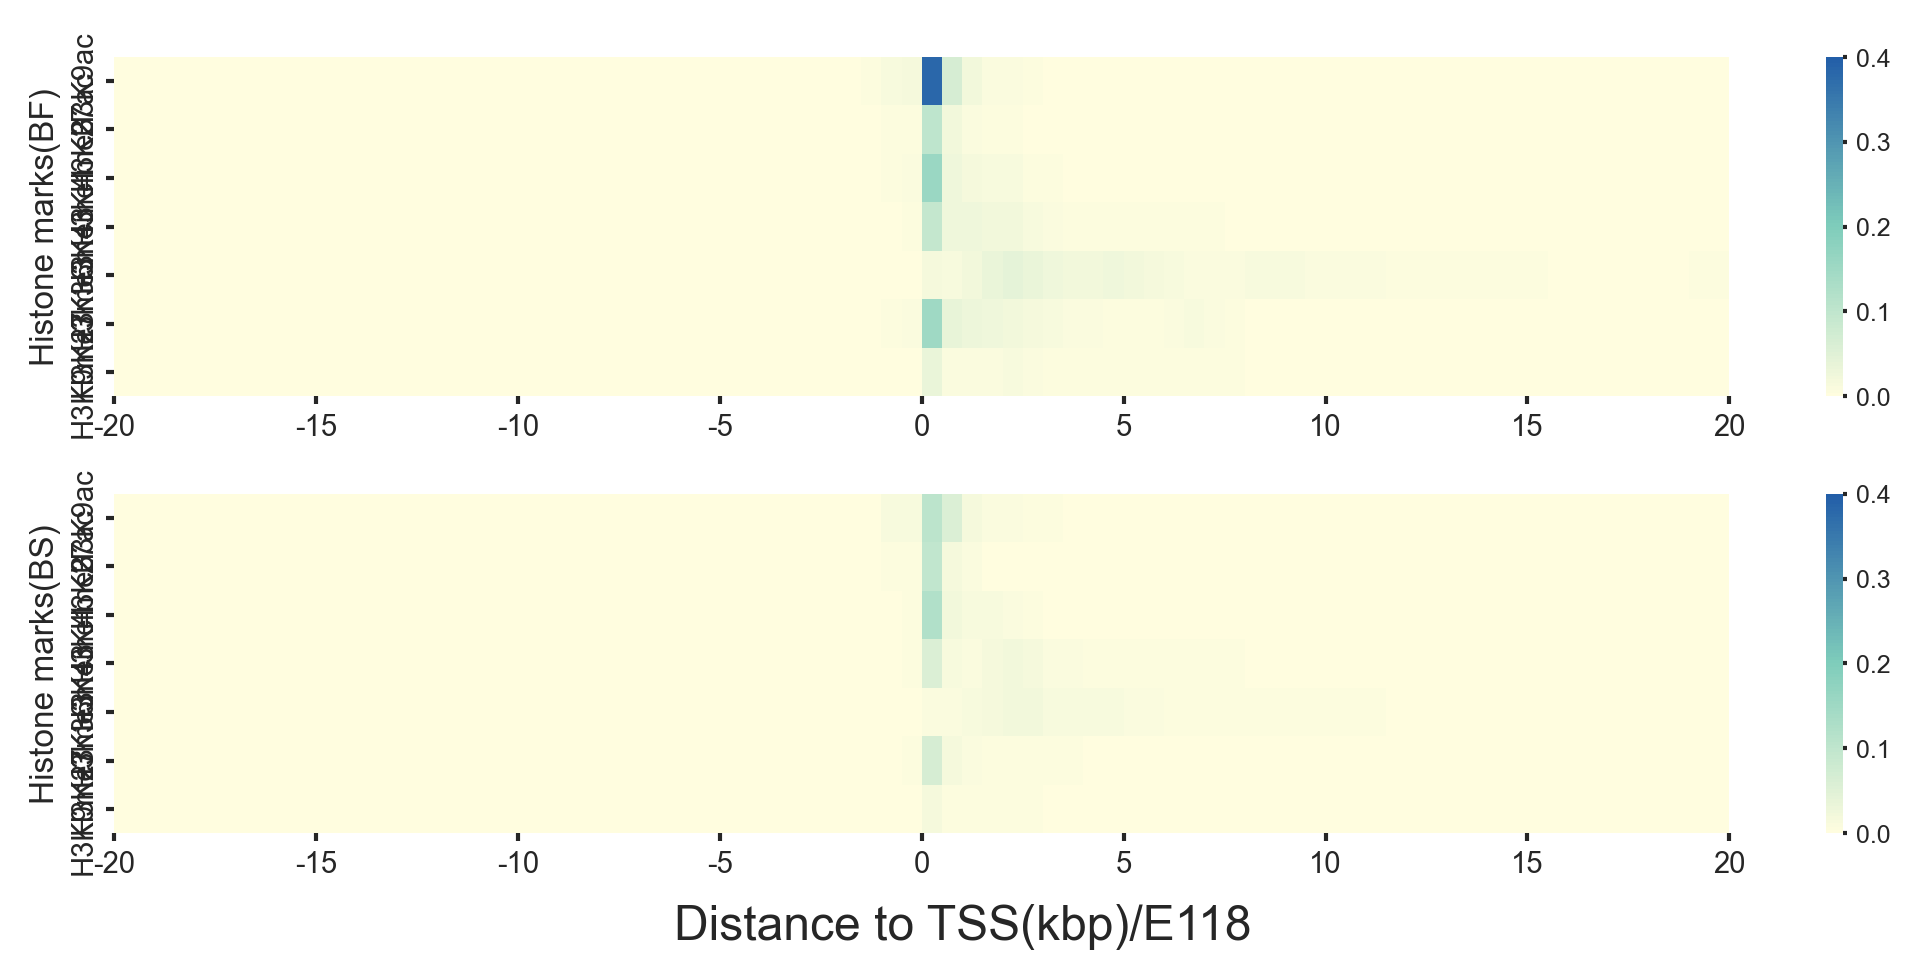

In [34]:
yticks = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
idxes = [MARKS.index(mark) for mark in yticks]

with open(f'extra/results/{eid}_bf_deeplift_attributions.npy','rb') as f:
   attributions1 =  np.load(f)
   attributions1 = attributions1[idxes]

with open(f'extra/results/{eid}_bs_deeplift_attributions.npy','rb') as f:
   attributions2 =  np.load(f)
   attributions2 = attributions2[idxes]

fig, ax =plt.subplots(2,1,constrained_layout=True)

xticks = [i for i in range(0,81,10)]
plot_heatmap(attributions1,axis=ax[0],ylabel="Histone marks(BF)",xticks=xticks,yticklabels=yticks)
plot_heatmap(attributions2,axis=ax[1],ylabel="Histone marks(BS)",xticks=xticks,yticklabels=yticks)

xticklabels = [int((i-40)/2) for i in range(0,81,10)]
ax[0].set_xticklabels(xticklabels)
ax[1].set_xticklabels(xticklabels)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}")
plt.savefig('extra/figures/Figure3.b.eps', format='eps', bbox_inches='tight')

# plt.ylabel(f"Importance")
plt.show()

### BS BF locations importance

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


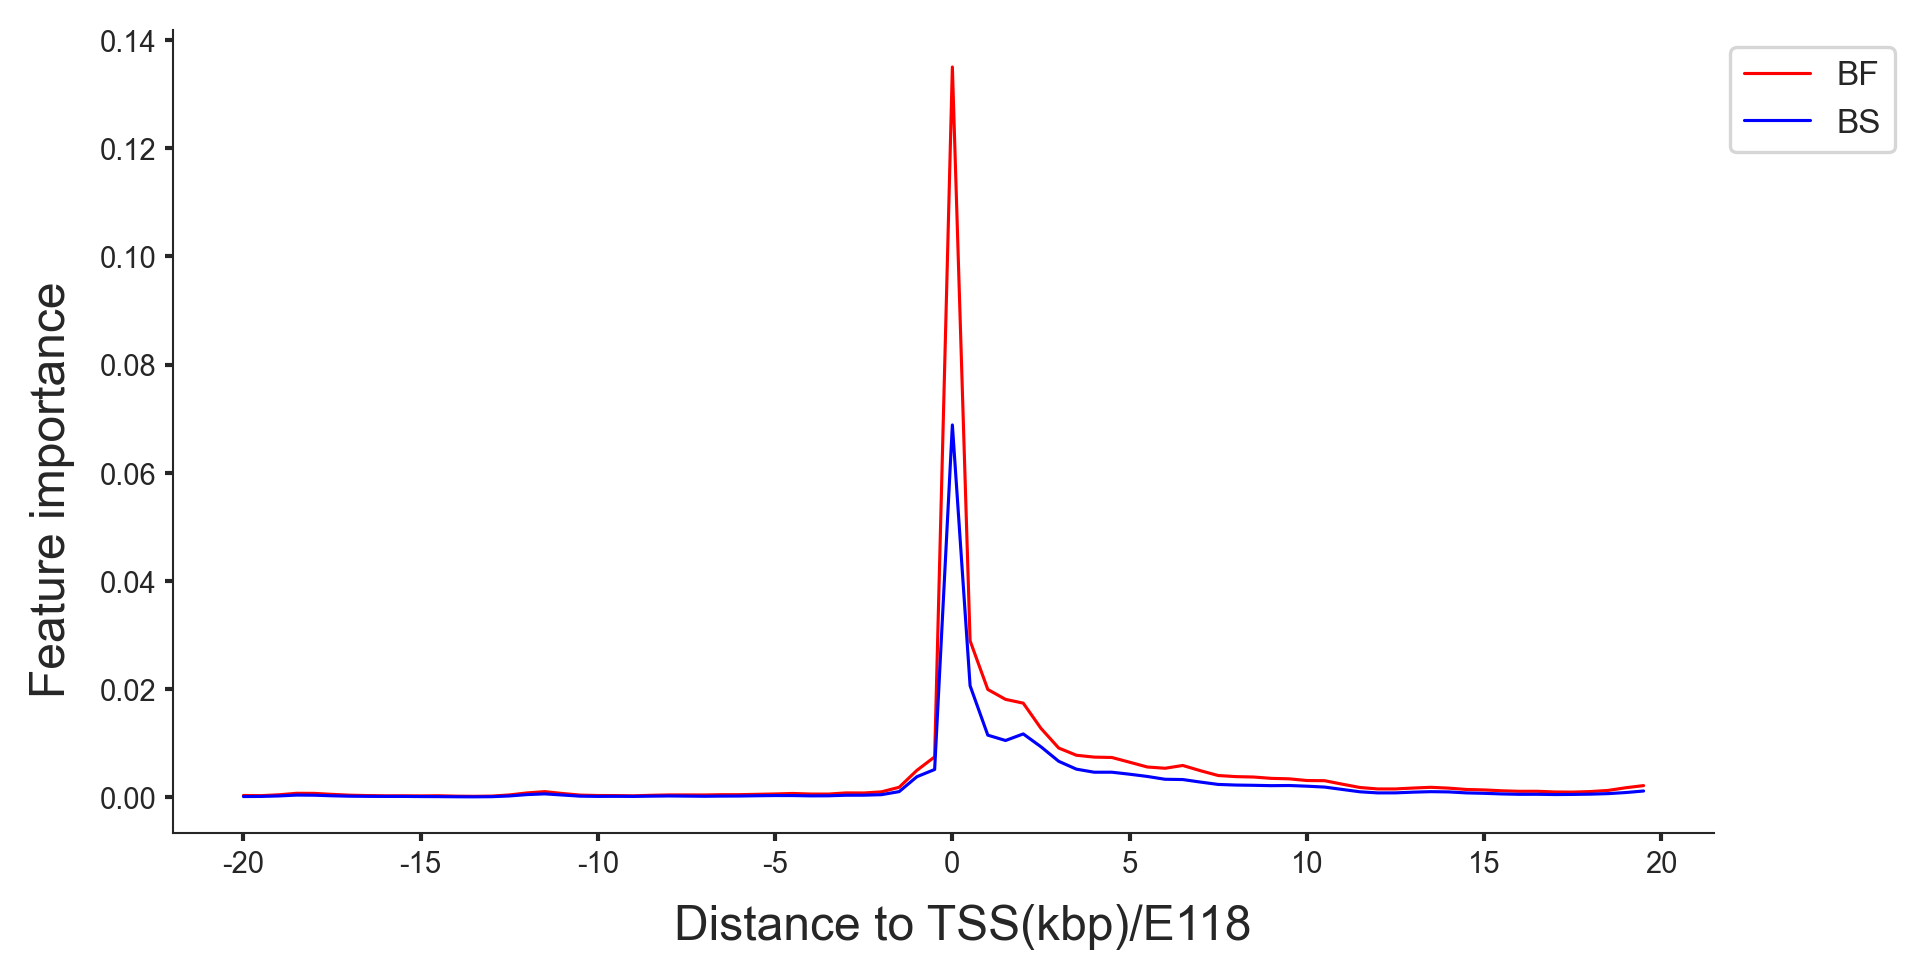

In [33]:
with open(f'extra/results/{eid}_bf_deeplift_distribution.npy','rb') as f:
   distribution1 =  np.load(f)

with open(f'extra/results/{eid}_bs_deeplift_distribution.npy','rb') as f:
   distribution2 =  np.load(f)

fig, ax =plt.subplots(1,1,constrained_layout=True)

g1 = sns.lineplot(distribution1, color='red', label = 'BF')
g2 = sns.lineplot(distribution2, color='blue', label = 'BS')
# Adjust layout to ensure everything fits
g1.legend(loc='upper left', bbox_to_anchor=(1, 1))
g1.set_xticks([i for i in range(0,81,10)])

xticklabels = [int((i-40)/2) for i in range(0,81,10)]
g1.set_xticklabels(xticklabels)
g2.set_xticklabels(xticklabels)

fig.supxlabel(f"Distance to TSS(kbp)/{eid}")
fig.supylabel(f"Feature importance")

plt.savefig('extra/figures/Figure3.a.eps', format='eps', bbox_inches='tight')
plt.show()